In [ ]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"./main_code")
import generate_data2,grid_cell,adaptive_int_fix,visual,cal_S_grad,org_m,mea_2D,net_2D_shape,S_valgrad,error_general_ada,main,ass_grad,main_fix
CUDA_LAUNCH_BLOCKING=1
def f_circle(x,x_left,x_right,y_below,y_upper,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2)
    r_y = np.linalg.norm(x - center, axis=-1)
    # Apply the piecewise function
    f_y_values = np.where(r_y < r , 1.0, 0.0)
    return f_y_values

cuda:0


In [3]:
from importlib import reload
reload(grid_cell)

<module 'grid_cell' from '/data5/store1/hxw/inverse_source/Kernet/2d_inverse_source_Kernet_DiriNeu_objects/one_object_支集为常数_中间/./main_code/main_code2/grid_cell.py'>

In [4]:
import copy
Nx,Ny=1,1
Ix,Iy=4,4  #x方向网格点
nx,ny=3,3  #每个网格x方向的高斯点
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89]
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max=-0.5,1.5,-0.5,1.5 #边界gamma处

num_batches_gauss=1
b_n=15
points_b=mea_2D.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) #在边界Γ处收集数据
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.2
center_true=np.array([0.5,0.5])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device=0
S_int_true_circle,F_mea_b_circle,F_mea_db_x1_circle,F_mea_db_x2_circle=generate_data2.boundary_data_circle(kk,number_gene,points_b,f_circle,x_left,x_right,y_below,y_upper,center_true,r_true,eps,mea,batch_number_rec_mea,device,cupy_device)
F=org_m.F(F_mea_b_circle,F_mea_db_x1_circle,F_mea_db_x2_circle)

cells= grid_cell.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) #创造初始网格
initial_cells=copy.deepcopy(cells) #copy一份
R_m=20
r_low,r_upper=0.18,0.2
b_below,b_upper=-0.51,-0.49

In [5]:
M=800
af="Tanh"   #先用tanh
R_m=20
cupy_device= 0

#models = net_2D_shape.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
models = net_2D_shape.local_rep(2,1,1,M,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],R_m_for_init=R_m,af=af,Shape=[],device=device).to(device)

In [ ]:
models=torch.load("./MA_RFM=5%/M=800*2_5%/models1_800.pth", map_location=device)

/tmp/ipykernel_3085990/2065966300.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  models=torch.load("./results/gradmesh/M=800*2_far_5%/models1_800.pth", map_location=dev

In [7]:
from importlib import reload
from re import S    
reload(main_fix)
reload(adaptive_int_fix)
reload(S_valgrad)

<module 'S_valgrad' from '/data5/store1/hxw/inverse_source/Kernet/2d_inverse_source_Kernet_DiriNeu_objects/one_object_支集为常数_中间/./main_code/main_code2/S_valgrad.py'>

/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


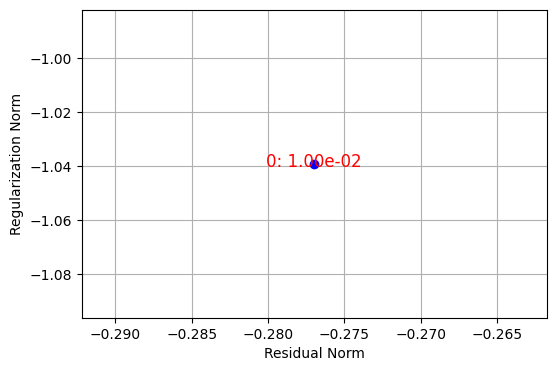

第 0 次迭代的train误差：


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/torch/autograd/graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


第 0 次迭代的泛化误差：


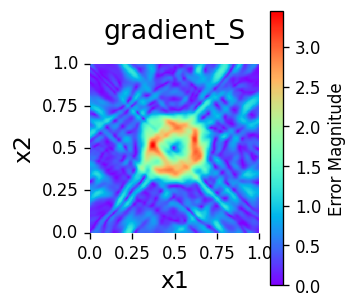

S_l_inf= 2.7592654142372566 S_L_2= 0.28858592320263254 S_l_2= 0.8177665545020407


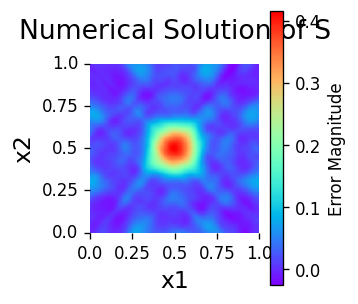

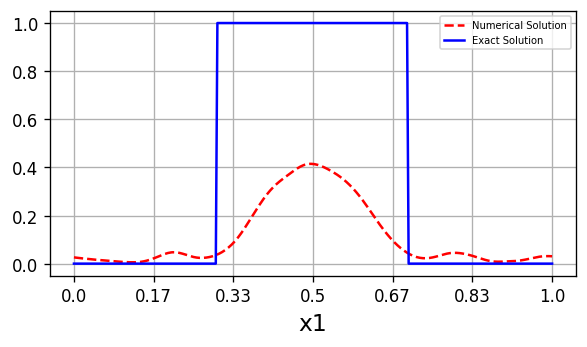

第 0 次自适应网格细分 (Diff Criterion)...
Generating visualizations...
1. Plotting mesh comparison...


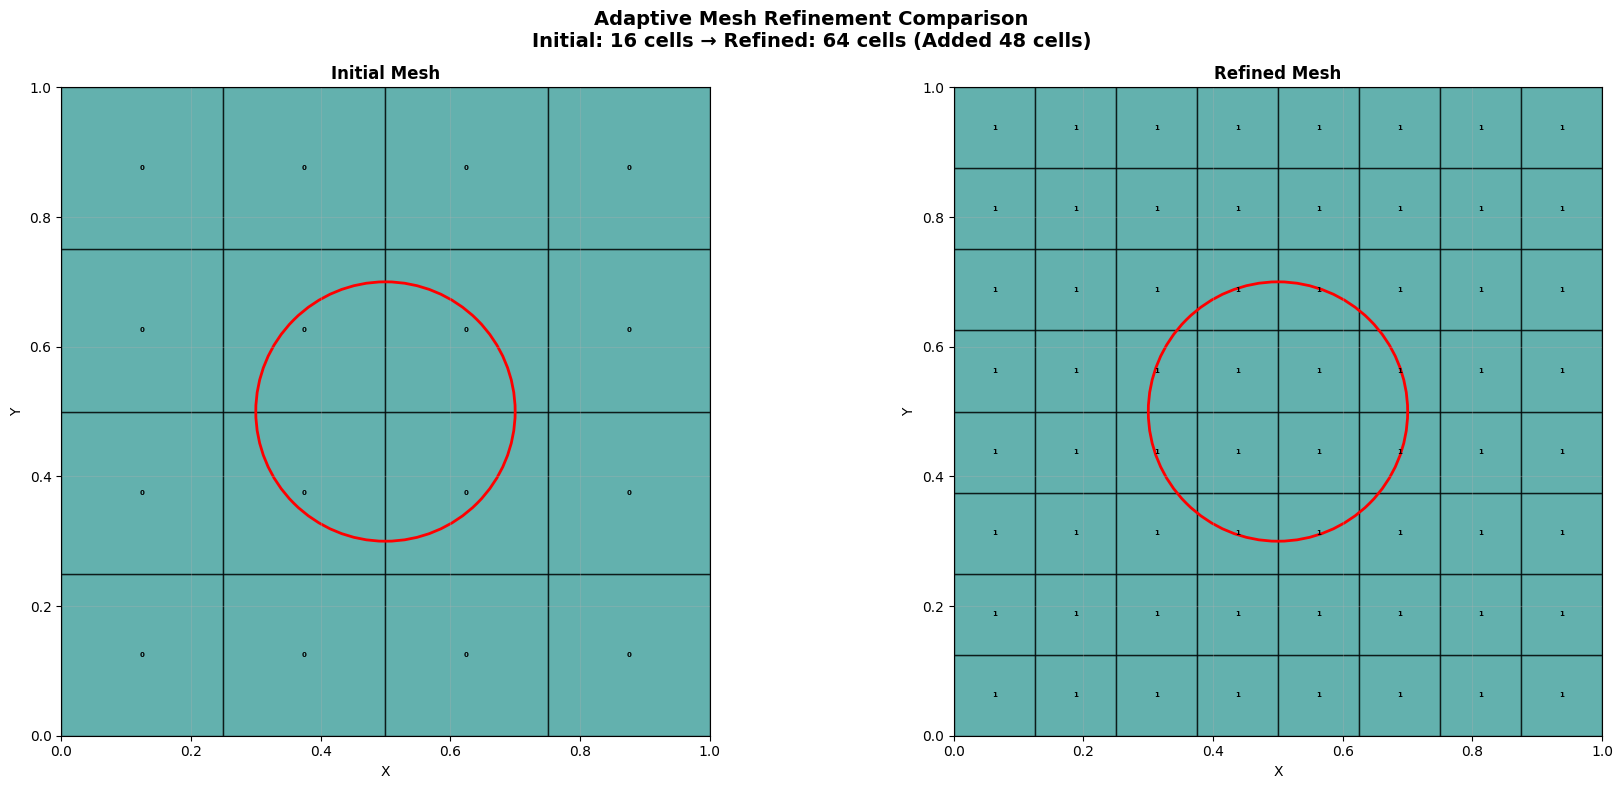

All visualizations completed!


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


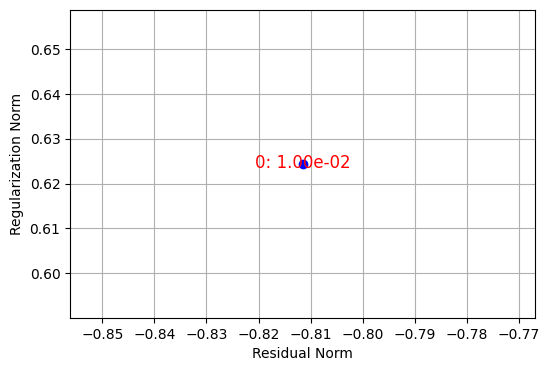

第 1 次迭代的train误差：
第 1 次迭代的泛化误差：


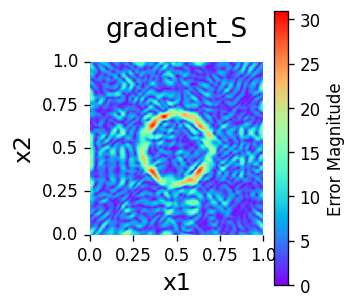

S_l_inf= 1.8782870254782535 S_L_2= 0.11709243208014854 S_l_2= 0.3318050779393449


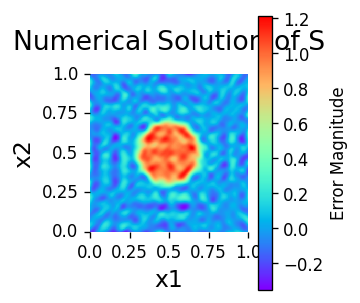

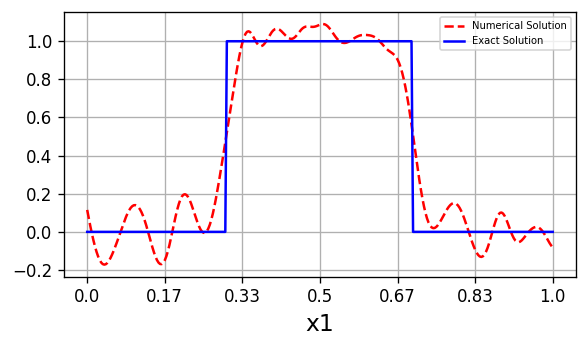

第 1 次自适应网格细分 (Diff Criterion)...
Generating visualizations...
1. Plotting mesh comparison...


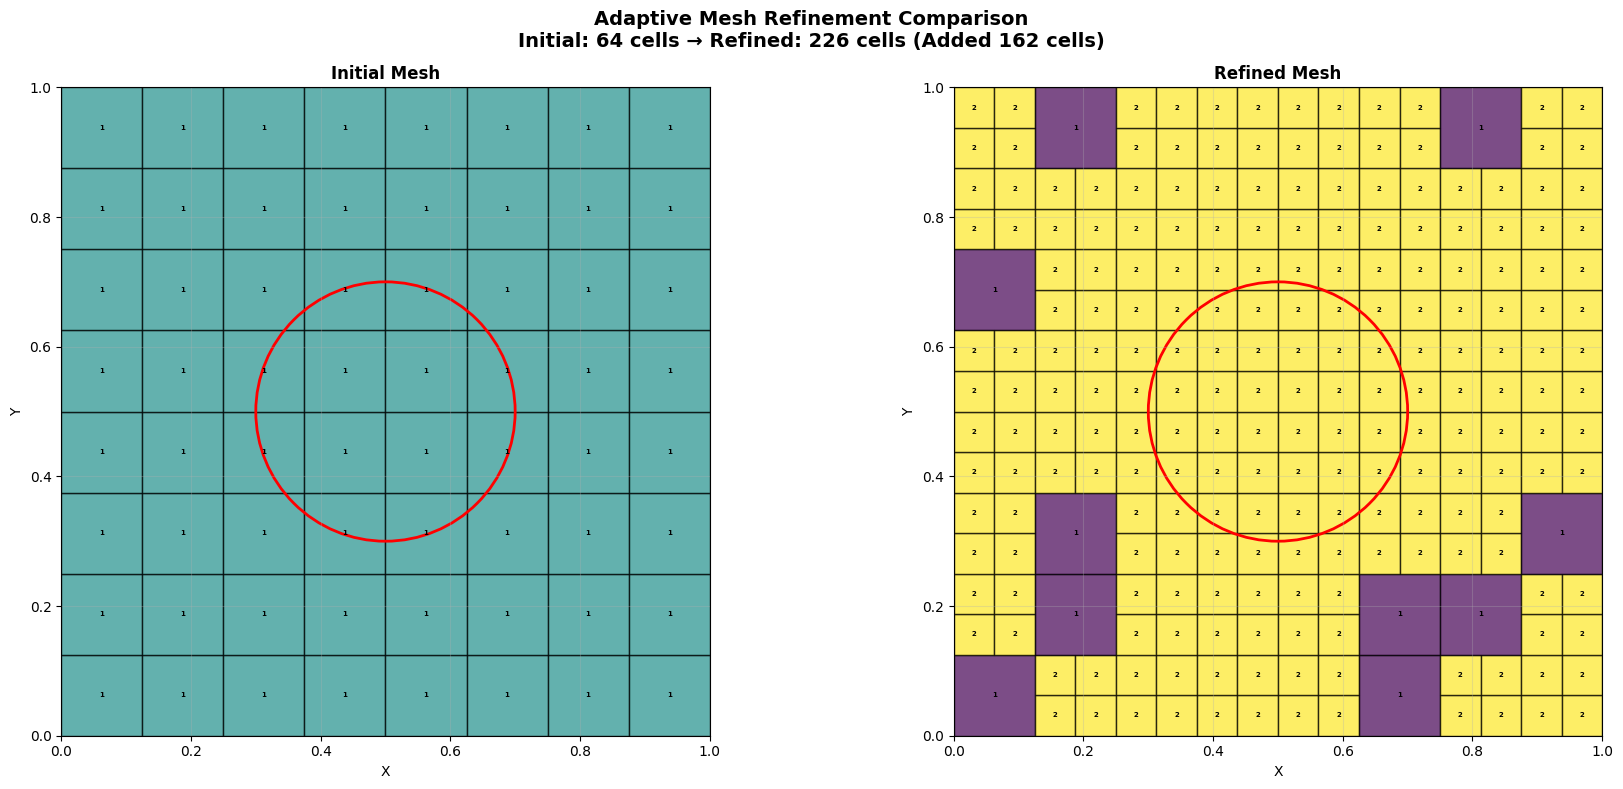

All visualizations completed!


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


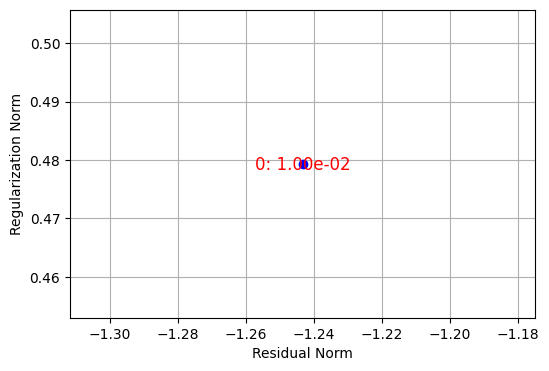

第 2 次迭代的train误差：
第 2 次迭代的泛化误差：


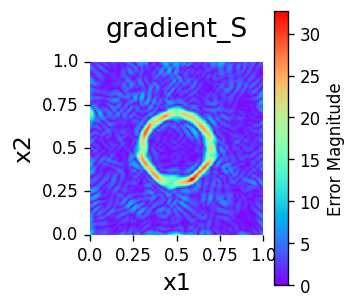

S_l_inf= 1.7204321160674898 S_L_2= 0.08029632352326985 S_l_2= 0.22753586556853425


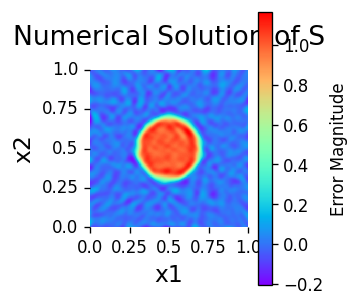

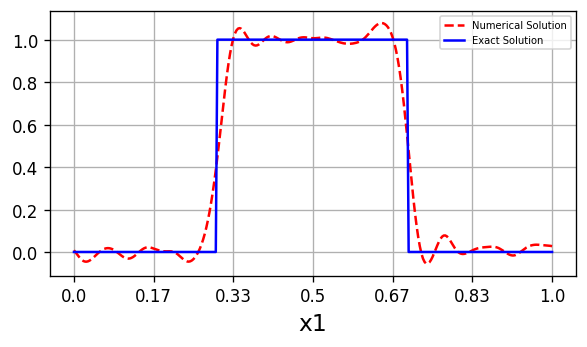

第 2 次自适应网格细分 (Diff Criterion)...
Generating visualizations...
1. Plotting mesh comparison...


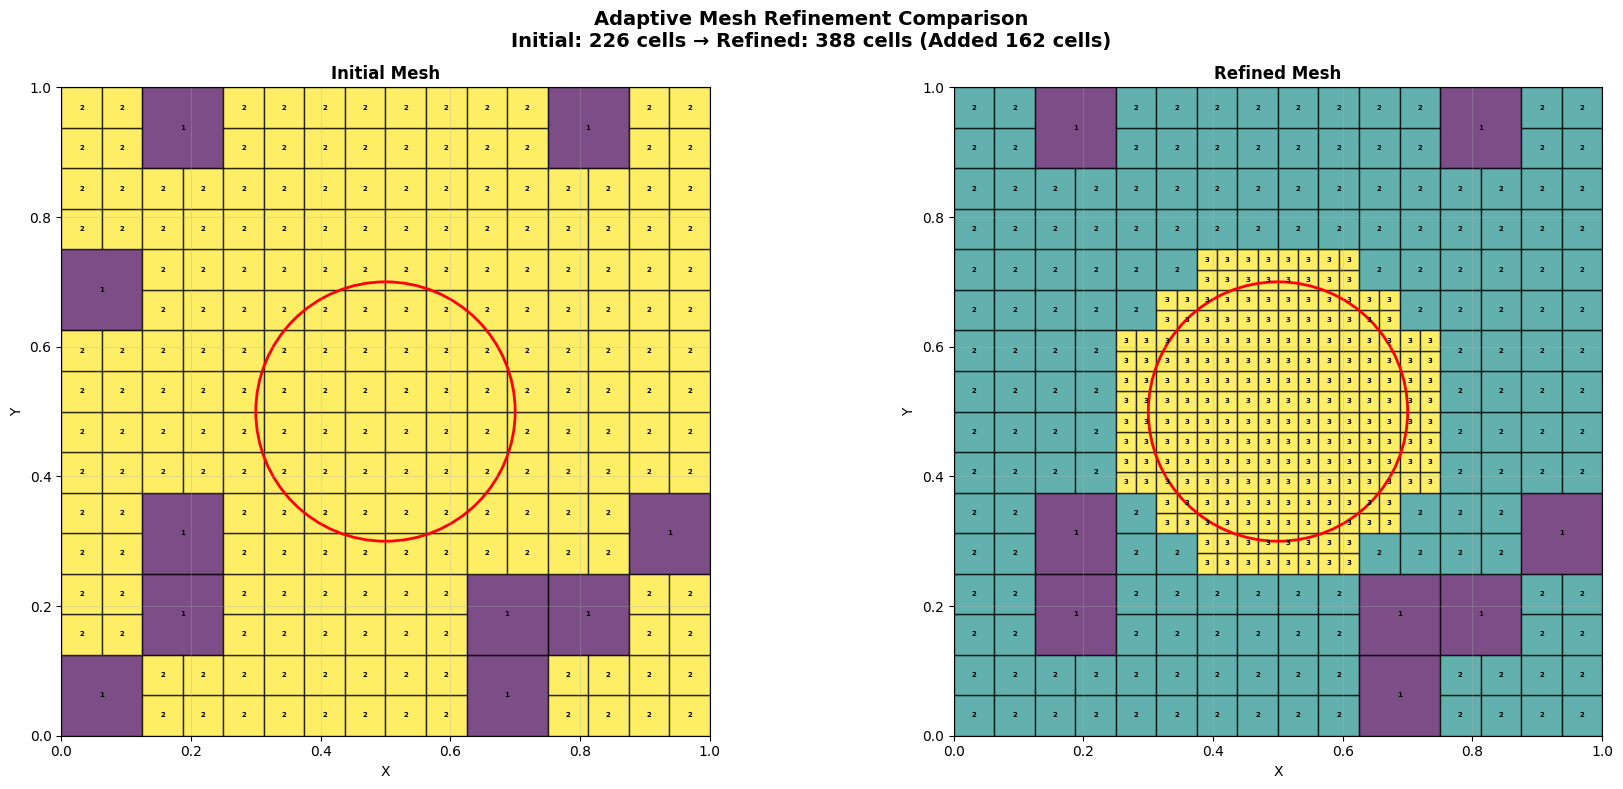

All visualizations completed!


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


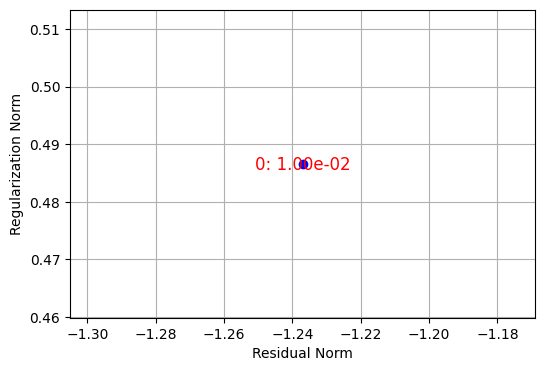

第 3 次迭代的train误差：
第 3 次迭代的泛化误差：


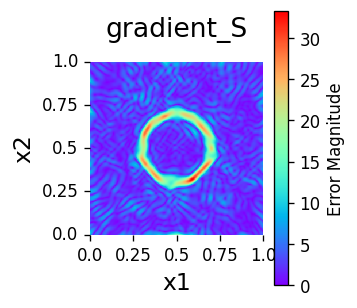

S_l_inf= 1.7072597820802844 S_L_2= 0.08030967931725302 S_l_2= 0.2275737119108196


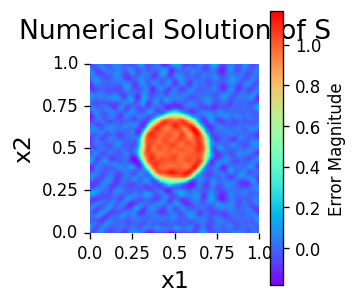

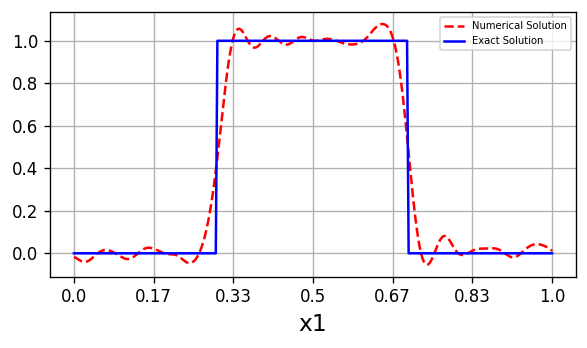

第 3 次自适应网格细分 (Diff Criterion)...
Generating visualizations...
1. Plotting mesh comparison...


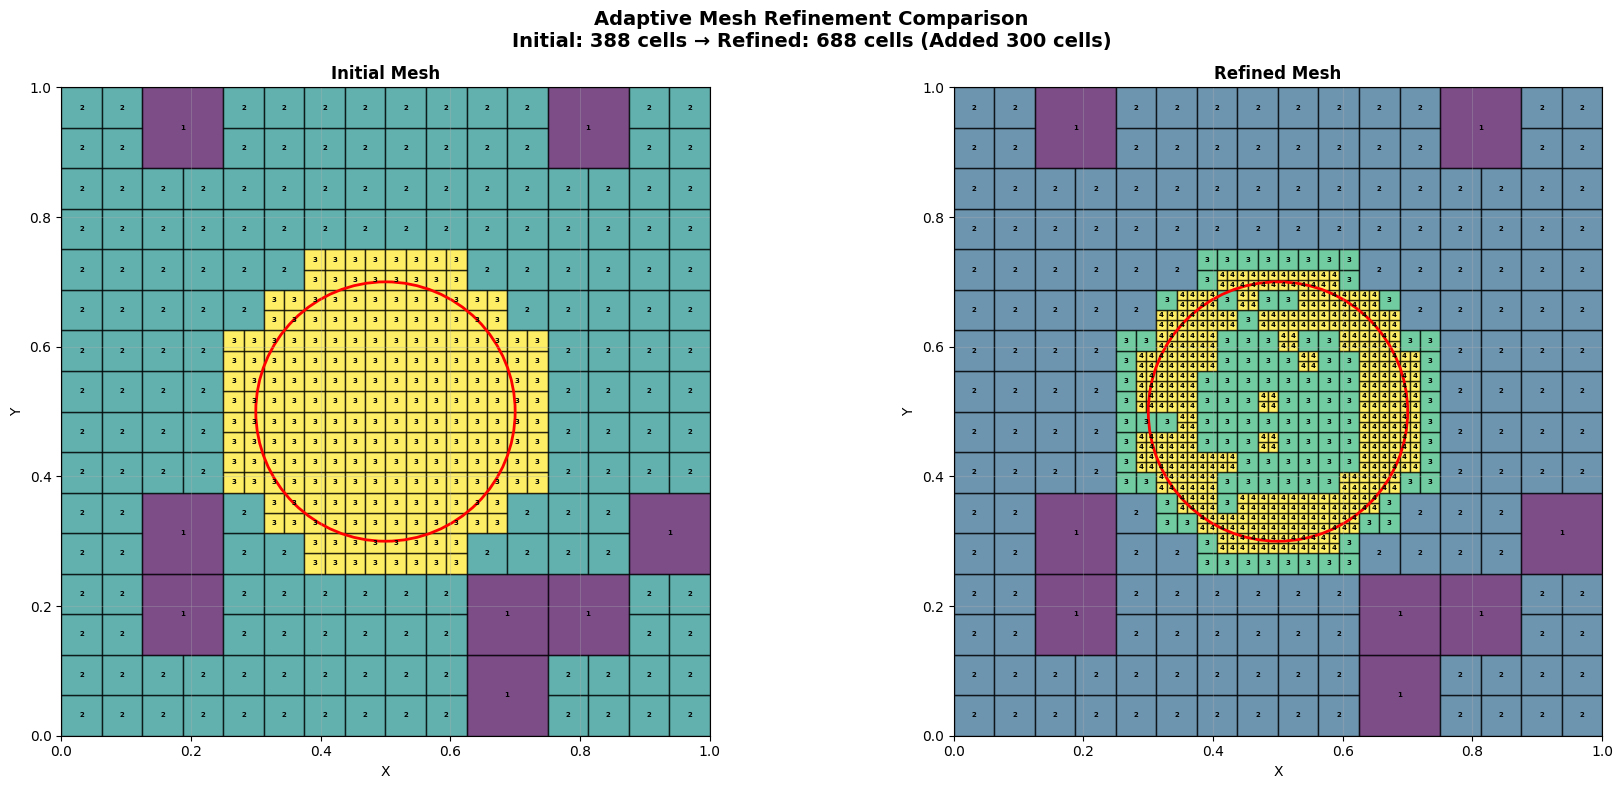

All visualizations completed!


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


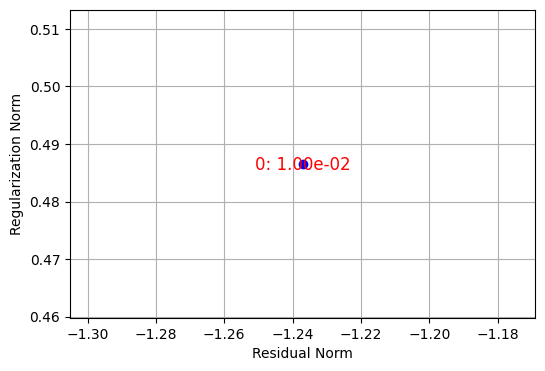

第 4 次迭代的train误差：
第 4 次迭代的泛化误差：


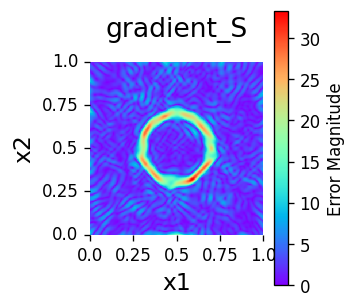

S_l_inf= 1.7073600777180262 S_L_2= 0.08031014154718737 S_l_2= 0.2275750217327839


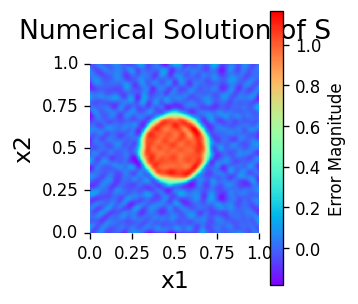

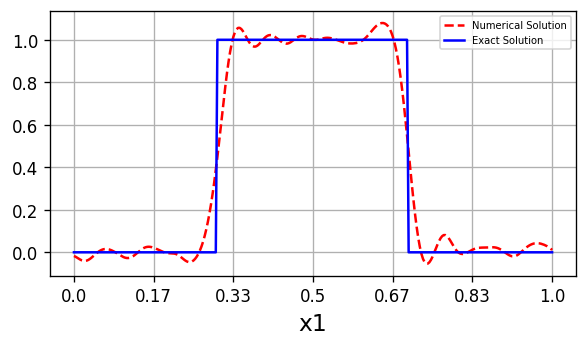

在第 4 次迭代结束


In [8]:
iter_int= 5
Ix,Iy=4,4  #x方向网格点
delta=10**(-3)
nx=3
lamb_regu=np.logspace(-2,-1,1)
Qx,Qy=150,150
max_level=4
current_maxiter=1
af="Tanh"
refine_threshold_S=[5e-5, 1e-4, 5e-4, 1e-3, 5e-3] #刚开始阈值小多细分，后面阈值大少细分
#refine_threshold_grad=[1e-7, 1e-7, 8e-7, 8e-7, 8e-7] #刚开始阈值小多细分，后面阈值大少细分
#refine_threshold_grad=[1e-8, 1e-8, 1e-7, 1e-7, 1e-6] #刚开始阈值小多细分，后面阈值大少细分
refine_threshold_grad=[5e-9, 1e-8, 5e-8, 1e-7, 5e-7]
refine_threshold_noise=[1e-2,1e-2,1e-2,1e-2,1e-2,1e-2]
# using main_fix.ada_int_fix
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_l2,S_num_store=main_fix.ada_int_fix(iter_int,delta,cells,nx,models,M,af,kk,F,tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_low,r_upper,center_true,r_true,f_circle,points_b,lamb_regu,Qx,Qy,device,cupy_device,refine_threshold_S,refine_threshold_grad,refine_threshold_noise,current_maxiter,max_level)

In [9]:
len(cells_store[-1])

688

In [ ]:
#保存cell_stores
import pickle
with open('./MA_RFM=5%/M=800*2_5%/cells_store.pkl', 'wb') as f:
    pickle.dump(cells_store, f)

In [ ]:
import pickle
#加载数据
with open('./MA_RFM=5%/M=800*2_5%/cells_store.pkl', 'rb') as f:
    cells_store = pickle.load(f)

In [12]:
import sys
sys.path.append(r"/data5/store1/hxw/inverse_source/AMain")  # 绝对路径
# 或
sys.path.append(r"../../AMain")  # 相对路径（从当前 notebook 位置）

import bound_detect
reload(bound_detect)

<module 'bound_detect' from '/data5/store1/hxw/inverse_source/Kernet/2d_inverse_source_Kernet_DiriNeu_objects/one_object_支集为常数_中间/./main_code/main_code2/bound_detect.py'>

Number of detected clusters: 1
Cluster 0: AR=1.01
  Res_Rect=0.098 vs Res_Ellip=0.017
  -> Winner: Circle
Cluster 0: Lx=0.400, Ly=0.403, AR=1.01
  -> Decision: Circle (Sigmoid)


/data5/store1/hxw/inverse_source/Kernet/2d_inverse_source_Kernet_DiriNeu_objects/one_object_支集为常数_中间/./main_code/main_code2/bound_detect.py:429: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


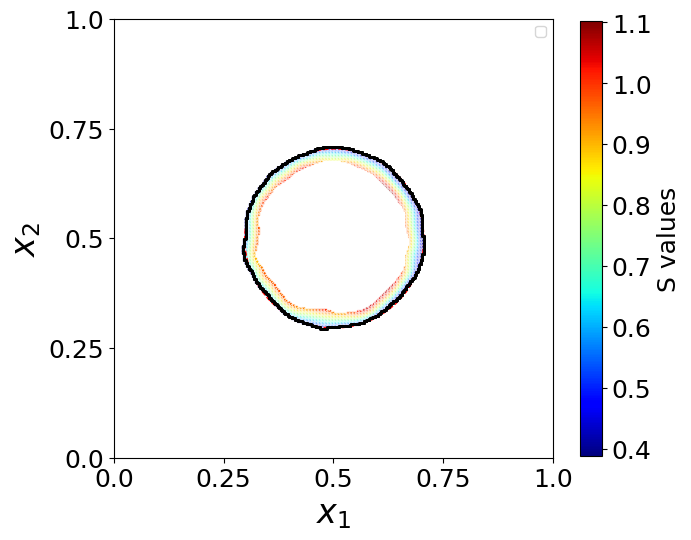

<Figure size 640x480 with 0 Axes>

In [ ]:
from importlib import reload
reload(bound_detect)
x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)
eps_cluster=0.02
mini_samples=20
para_abs=3
para_grad=3
results=bound_detect.detect_shape(g_S,X.T,Y.T,tau_x_min,tau_x_max,tau_y_min,tau_y_max,para_abs,para_grad,eps_cluster,mini_samples,S_num_store[-1],output_directory="./MA_RFM=5%/M=800*2_5%", output_filename="plot.png")

In [14]:
results

[{'cluster_id': 0,
  'shape': 'Circle',
  'params': {'center': array([0.50216672, 0.49949243]),
   'radius': np.float64(0.20404568441560525)},
  'profile': 'Sigmoid'}]

In [15]:
center=results[0]['params']['center']
r = results[0]['params']['radius']

In [24]:
import net_2D_fix2

r_min=r*(1-0.1)
r_max=r*(1+0.05)
K_min=1000
K_max=20000
b1_min=-center[0]*(1+0.05)
b1_max=-center[0]*(1-0.05)
b2_min=-center[1]*(1+0.05)
b2_max=-center[1]*(1-0.05)
models1=models
models2=net_2D_shape.local_rep(2,1,1,M,tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_min,r_max,b1_min,b1_max,b2_min,b2_max,[],[],[],[],[],[],[],[],K_min,K_max,R_m_for_init=R_m,af="sigmoid",Shape="circle",device=device).to(device)
#models2= net_2D_shape.pre_define(Nx,Ny,M,R_m,"sigmoid",tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_min,r_max,b1_min,b1_max,b2_min,b2_max,[],[],[],[],[],[],[],[],K_min,K_max,"circle",device)
af="mix"
sum_mat,all_g_p1,all_g_n,cells_copy1,rrr,sss=ass_grad.mat_assemble(cells_store[-1],models1,models2,[],"mix","circle",[],kk,0,points_b,0,device,cupy_device)

/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


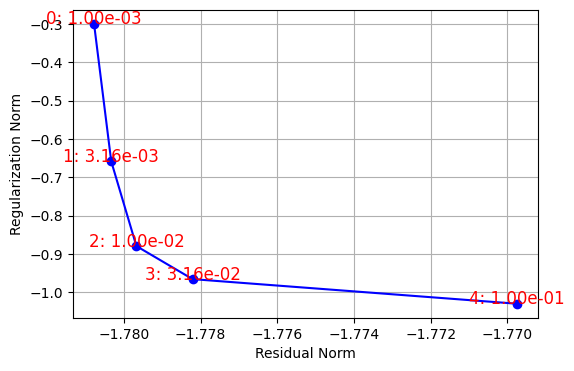

In [25]:
lamb_regu=np.logspace(-3,-1,5,endpoint=True)
res,reg_norm,w_store=org_m.L_curve(sum_mat,F,[],[],[],lamb_regu,"linear",device,cupy_device) #先进行求解

lamb: 0.0009999999999999998
S_l_inf= 1.5315995720956375 S_L_2= 0.04906093473760398 S_l_2= 0.13902407683568505


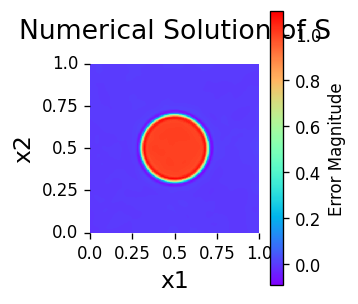

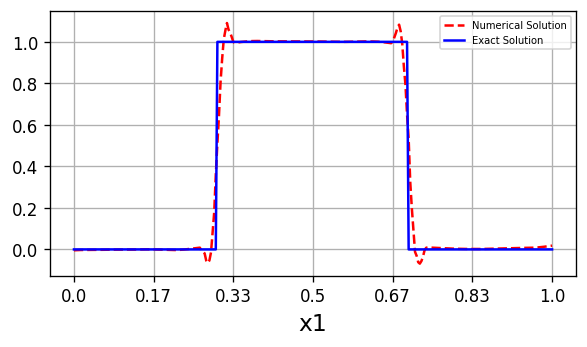

In [36]:
lamb=lamb_regu[3]**2
print('lamb:',lamb)
S_test_num,S_test_true,S_l_inf1,S_l_21,g_SS=error_general_ada.test(models1,models2,[],M,Qx,Qy,w_store[:,3
                                                                                                      ],af,"circle",[],True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],center_true,r_true,f_circle,0,device)

In [ ]:
torch.save(models1,"./MA_RFM=5%/M=800*2_5%/models1_800.pth")

In [ ]:
torch.save(models2,"./MA_RFM=5%/M=800*2_5%/models1_sig_33_800.pth")

In [ ]:
np.save("./MA_RFM=5%/M=800*2_5%/g_S",g_S)
np.save("./MA_RFM=5%/M=800*2_5%/S_l2",S_l2)
np.save("./MA_RFM=5%/M=800*2_5%/S_num_store",S_num_store)
np.save("./MA_RFM=5%/M=800*2_5%/S_num_MA-RFM_800",S_test_num)
np.save("./MA_RFM=5%/M=800*2_5%/all_mat",sum_mat)
np.save("./MA_RFM=5%/M=800*2_5%/w_store",w_store)
np.save("./MA_RFM=5%/M=800*2_5%/F_mea_b",F_mea_b_circle)
np.save("./MA_RFM=5%/M=800*2_5%/F_mea_db_x1",F_mea_db_x1_circle)
np.save("./MA_RFM=5%/M=800*2_5%/F_mea_db_x2",F_mea_db_x2_circle)

In [30]:
parameters0 = {
    "I_grid":Ix,
    "gauss_n":nx,
    "number_gene":number_gene,
    "noise":eps,
    "k": kk,
    "M0": M,
    "M1": M,
    "Tanh_Rm":20,
    "Gauss_R_m": R_m,
    "refinement_stats_store":refinement_stats_store,
    "points_number_ada:":point_number,
    "center":center,
    "r":r,
    "r_min": r_min,
    "r_max": r_max,
    "b1_min": b1_min,
    "b1_max": b1_max,
    "b2_min": b2_min,
    "b2_max": b2_max,
    "K_min": K_min,
    "K_max": K_max,
}

In [ ]:
import pickle # 导入 pickle 模块
output_pickle_file = "./MA_RFM=5%/M=800*2_5%/parameters.pkl"
with open(output_pickle_file, 'wb') as f: # 'wb' for write binary
    pickle.dump(parameters0, f)

In [32]:
n_integral=len(cells_store[-1])*9
print('n_integral:',n_integral)
print('center:',center)


print('r:',r)
print('S_l2[-1]:',S_l2[-1])
print('lamb_regu:',lamb)
print('S_l21:',S_l_21)

n_integral: 6192
center: [0.50216672 0.49949243]
r: 0.20404568441560525
S_l2[-1]: 0.2275750217327839
lamb_regu: 0.0009999999999999998
S_l21: 0.13902407683568505
